In [ ]:
import networkx as nx
from matplotlib import pyplot as plt
from shapely.geometry import LineString, MultiLineString
from shapely.ops import unary_union, polygonize

# LSD method

Original lines detected: 11
Lines detected: 11


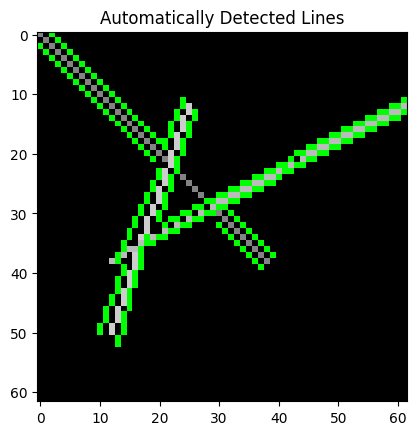

In [532]:
# Let's define a function that attempts to detect the lines automatically
def automatic_line_detection(image):
    # Convert the image to grayscale if it's not already
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    H, W = image.shape[:2]
    lsd = cv2.createLineSegmentDetector(0)

    lines = lsd.detect(gray)[0]

    # Initialize an empty list to hold the clamped lines
    clamped_lines = []

    for line in lines:
        x1, y1, x2, y2 = line[0]

        # Clamp the coordinates
        x1 = min(max(round(x1), 0), W - 1)
        y1 = min(max(round(y1), 0), H - 1)
        x2 = min(max(round(x2), 0), W - 1)
        y2 = min(max(round(y2), 0), H - 1)

        # Append the clamped line to the list
        clamped_lines.append([x1, y1, x2, y2])

    print(f'Original lines detected: {len(lines)}')

    # Draw lines on a copy of the original image
    drawn_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR) if len(image.shape) == 2 else image.copy()
    if clamped_lines is not None:
        print(f"Lines detected: {len(lines)}")
        for line in clamped_lines:
            x1, y1, x2, y2 = line
            cv2.line(drawn_img, (x1, y1), (x2, y2), (0, 255, 0), 1)

    # Show the detected lines
    plt.imshow(cv2.cvtColor(drawn_img, cv2.COLOR_BGR2RGB))
    plt.title('Automatically Detected Lines')
    plt.show()

    return lines

image = cv2.imread("../../output/exported_img_comp.png")
# Run the automatic line detection on the new image
detected_lines_automatic = automatic_line_detection(image)

# Generate test image

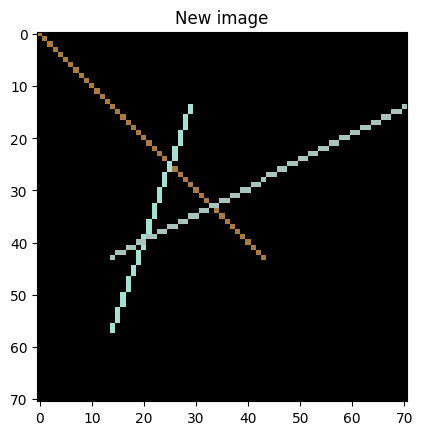

In [534]:
import os

output_folder = "../../output"
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

coef = 7
line_width = 1
new_img = np.zeros((round(500 / coef), round(500 / coef), 3), dtype=np.uint8)
cv2.line(new_img, (0, 0), (round(300 / coef), round(300 / coef)), (63, 124, 172), line_width)
cv2.line(new_img, (round(200 / coef), round(100 / coef)), (round(100 / coef), round(400 / coef)), (213, 225, 163), line_width)
cv2.line(new_img, (round(100 / coef), round(300 / coef)), (round(500 / coef), round(100 / coef)), (189, 196, 167), line_width)
cv2.imwrite(f"{output_folder}/img.png", new_img)
plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB))
plt.title('New image')
plt.show()

# Convert image to the gray

In [535]:
# Converter
image_to_export = cv2.imread("../../output/img.png")
# Convert the image to grayscale if it's not already
if len(image_to_export.shape) == 3:
    gray = cv2.cvtColor(image_to_export, cv2.COLOR_BGR2GRAY)
else:
    gray = image
    
output_folder="../../output/"
cv2.imwrite(f"{output_folder}/exported_img.png", gray)
cv2.imwrite(f"{output_folder}/exported_img_comp.png", gray)

True

# Compress the image

In [426]:
from PIL import Image

def compress_and_resize(image_path, output_path, new_width, new_height, quality):
    # Open the image
    with Image.open(image_path) as img:
        # Resize the image
        img = img.resize((new_width, new_height))

        # Save the image with specified quality
        # Quality is an integer between 0 (worst) to 100 (best)
        img.save(output_path, quality=quality, optimize=True)
        
compress_and_resize("../../output/exported_img.png", "../../output/exported_img_comp.png", 50, 50, 100)

# Hough Transform

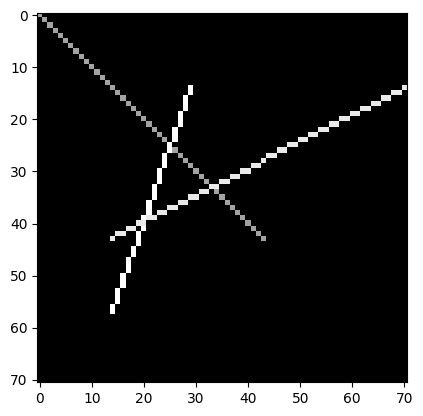

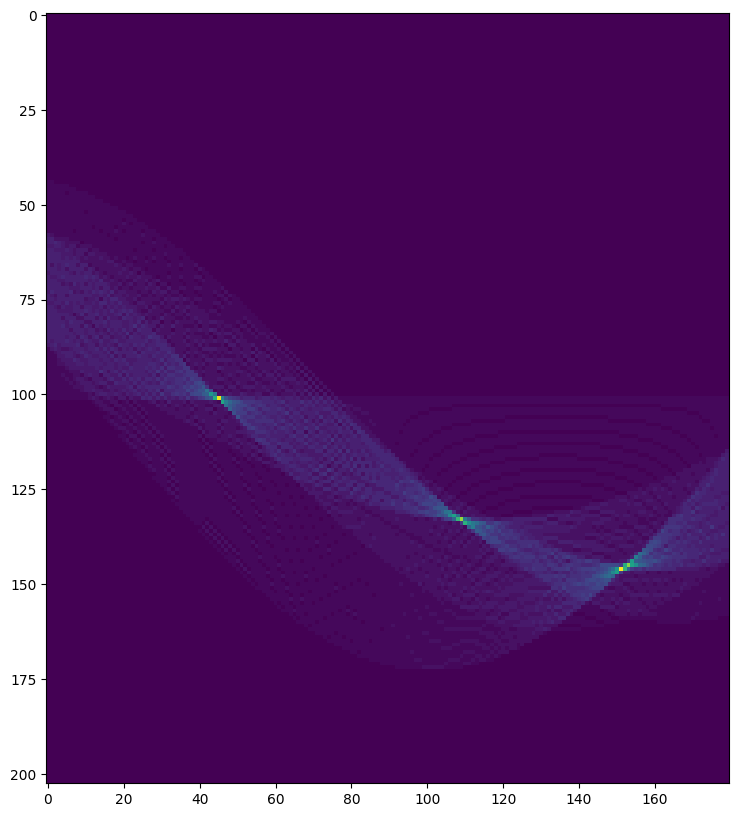

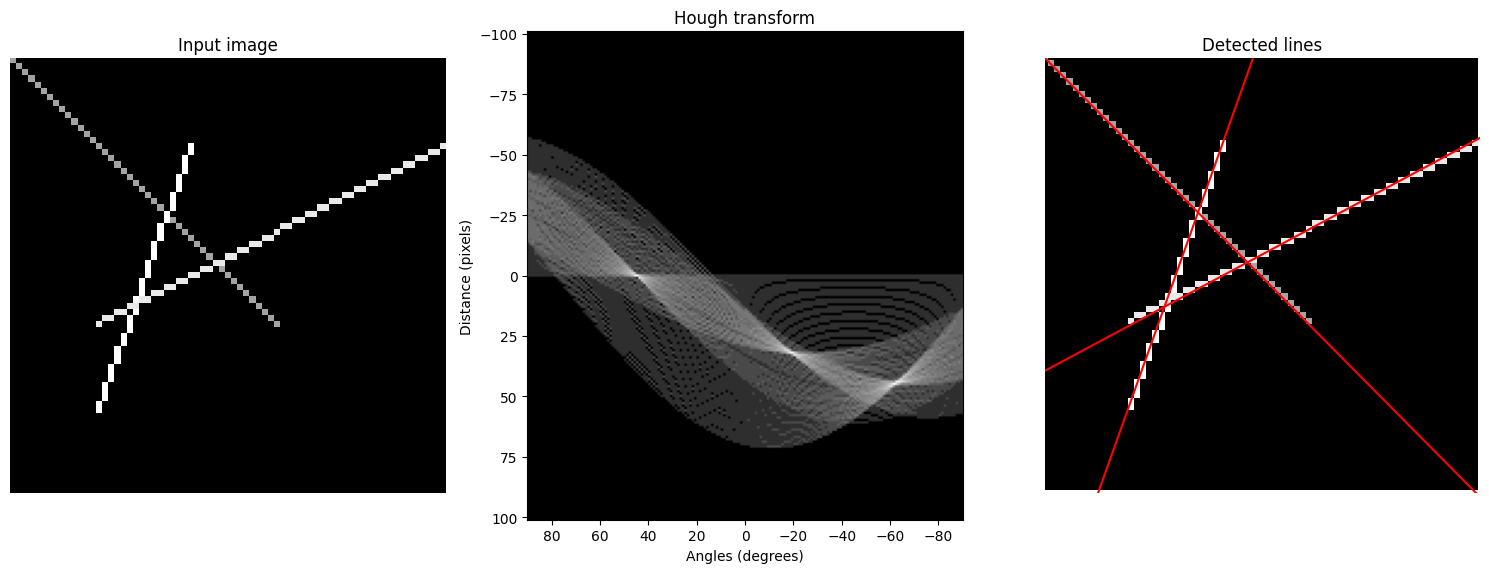

73.4078212290503


In [536]:
from skimage.transform import (hough_line, hough_line_peaks)
import numpy as np
import cv2
from matplotlib import pyplot as plt

image = cv2.imread('../../output/exported_img_comp.png', 0) #Fails if uses as-is due to bright background.
#Also try lines2 to see how it only picks up straight lines
#Invert images to show black background
# image = ~image  #Invert the image (only if it had bright background that can confuse hough)
plt.imshow(image, cmap='gray')

# Set a precision of 1 degree. (Divide into 180 data points)
# You can increase the number of points if needed. 
tested_angles = np.linspace(-np.pi / 2, np.pi / 2, 180)

# Perform Hough Transformation to change x, y, to h, theta, dist space.
hspace, theta, dist = hough_line(image, tested_angles)

plt.figure(figsize=(10,10))
plt.imshow(hspace)  


#Now, to find the location of peaks in the hough space we can use hough_line_peaks
h, q, d = hough_line_peaks(hspace, theta, dist)


#################################################################
#Example code from skimage documentation to plot the detected lines
angle_list=[]  #Create an empty list to capture all angles

# Generating figure 1
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Input image')
ax[0].set_axis_off()

ax[1].imshow(np.log(1 + hspace),
             extent=[np.rad2deg(theta[-1]), np.rad2deg(theta[0]), dist[-1], dist[0]],
             cmap='gray', aspect=1/1.5)
ax[1].set_title('Hough transform')
ax[1].set_xlabel('Angles (degrees)')
ax[1].set_ylabel('Distance (pixels)')
ax[1].axis('image')

ax[2].imshow(image, cmap='gray')

origin = np.array((0, image.shape[1]))

for _, angle, dist in zip(*hough_line_peaks(hspace, theta, dist)):
    angle_list.append(angle) #Not for plotting but later calculation of angles
    y0, y1 = (dist - origin * np.cos(angle)) / np.sin(angle)
    ax[2].plot(origin, (y0, y1), '-r')
ax[2].set_xlim(origin)
ax[2].set_ylim((image.shape[0], 0))
ax[2].set_axis_off()
ax[2].set_title('Detected lines')

plt.tight_layout()
plt.show()

###############################################################
# Convert angles from radians to degrees (1 rad = 180/pi degrees)
angles = [a*180/np.pi for a in angle_list]

# Compute difference between the two lines
angle_difference = np.max(angles) - np.min(angles)
print(180 - angle_difference)   #Subtracting from 180 to show it as the small angle between two lines

# Probabilistic Hough

Lines detected: 7


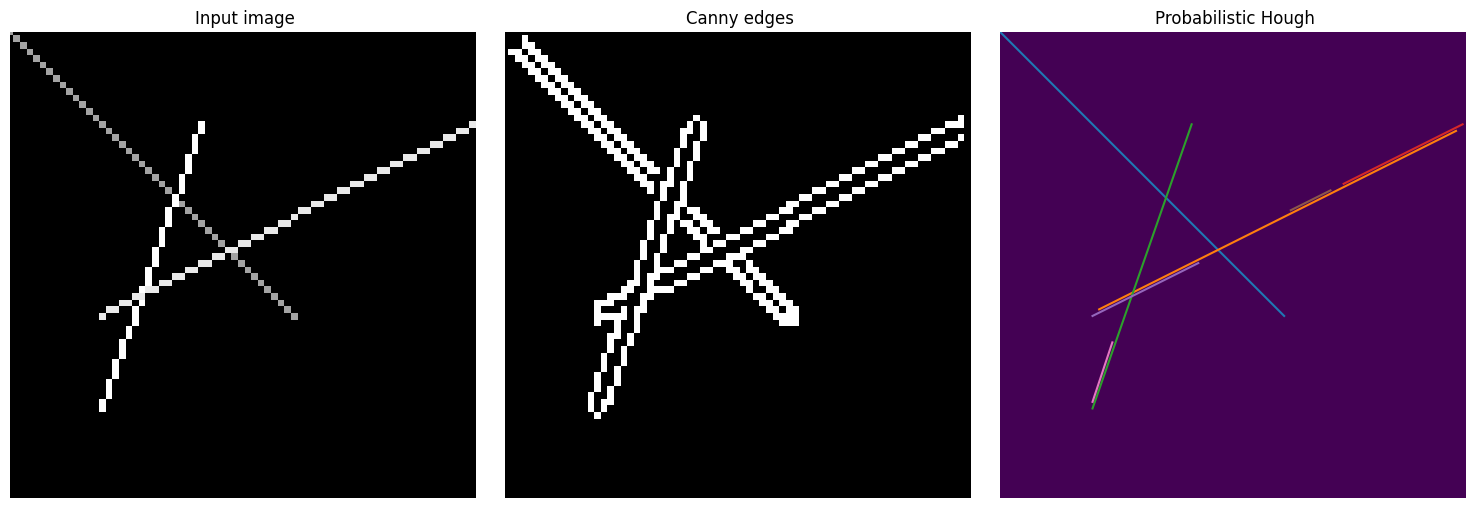

In [544]:
from skimage.transform import probabilistic_hough_line
from skimage.feature import canny
from matplotlib import cm

# Line finding using the Probabilistic Hough Transform
image = cv2.imread('../../output/exported_img_comp.png', 0) #Fails if uses as-is due to bright background.
edges = canny(image, sigma=1.0, low_threshold=10, high_threshold=20)
lines = probabilistic_hough_line(image, threshold=10, line_length=2, line_gap=5)

print(f"Lines detected: {len(lines)}")
        
# Generating figure 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=cm.gray)
ax[0].set_title('Input image')

ax[1].imshow(edges, cmap=cm.gray)
ax[1].set_title('Canny edges')

ax[2].imshow(edges * 0)
for line in lines:
    p0, p1 = line
    ax[2].plot((p0[0], p1[0]), (p0[1], p1[1]))
ax[2].set_xlim((0, image.shape[1]))
ax[2].set_ylim((image.shape[0], 0))
ax[2].set_title('Probabilistic Hough')

for a in ax:
    a.set_axis_off()

plt.tight_layout()
plt.show()

[((0, -8.408823765255514e-18), (43, 42.99999999999998)), ((14, 42.74947447447449), (70, 14.026351351351352)), ((14, 56.20588235294116), (29, 13.852941176470551))]
Lines found: 3


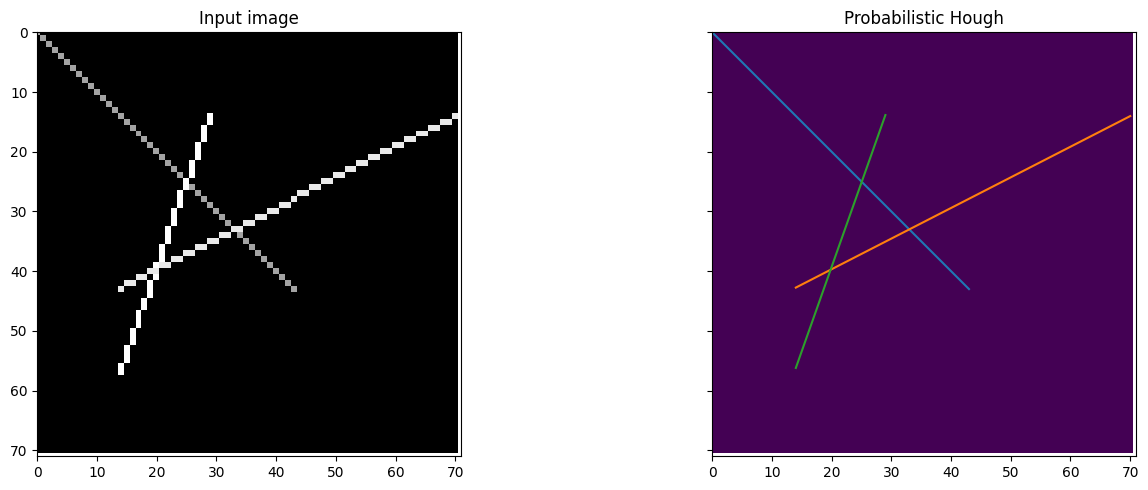

In [545]:
import numpy as np
from math import atan2, degrees

# A function to calculate the angle of a line
def calculate_angle(line):
    p0, p1 = line
    return degrees(atan2(p1[1] - p0[1], p1[0] - p0[0]))

# A function to check if two angles are similar
def are_similar(angle1, angle2, threshold=5):
    return abs(angle1 - angle2) < threshold

# Calculate angles for each line and store them
angles = [calculate_angle(line) for line in lines]

# Cluster lines by angle
clusters = {}
for idx, angle in enumerate(angles):
    found_cluster = False
    for cluster_angle in clusters.keys():
        if are_similar(angle, cluster_angle):
            clusters[cluster_angle].append(lines[idx])
            found_cluster = True
            break
    if not found_cluster:
        clusters[angle] = [lines[idx]]

# Assuming clusters is a dictionary with angles as keys and lists of lines as values
unioned_lines = []

for angle, lines_n in clusters.items():
    # Extract endpoints for all lines in the cluster
    x_coords = []
    y_coords = []
    for line in lines_n:
        p0, p1 = line
        x_coords.extend([p0[0], p1[0]])
        y_coords.extend([p0[1], p1[1]])
    
    # Perform linear regression on the endpoints
    A = np.vstack([x_coords, np.ones(len(x_coords))]).T
    m, c = np.linalg.lstsq(A, y_coords, rcond=None)[0]
    
    # Determine the new endpoints for the unioned line
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = m*x_min + c, m*x_max + c
    
    # Add the new line to the list of unioned lines
    unioned_lines.append(((x_min, y_min), (x_max, y_max)))
    
print(unioned_lines)

print(f"Lines found: {len(unioned_lines)}")

# Generating figure 2
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=cm.gray)
ax[0].set_title('Input image')

ax[1].imshow(edges * 0)
for line in unioned_lines:
    p0, p1 = line
    ax[1].plot((p0[0], p1[0]), (p0[1], p1[1]))
ax[1].set_xlim((0, image.shape[1]))
ax[1].set_ylim((image.shape[0], 0))
ax[1].set_title('Probabilistic Hough')

# for a in ax:
    # a.set_axis_off()

plt.tight_layout()
plt.show()

Lines: [((0, -8.408823765255514e-18), (43, 42.99999999999998)), ((14, 42.74947447447449), (70, 14.026351351351352)), ((14, 56.20588235294116), (29, 13.852941176470551))]
[(33.00272925764194, 33.002729257641924), (25.038461538461537, 25.038461538461526), (19.823730543408445, 39.76240787743497)]
Lines found: 3
INtersection points found: 3


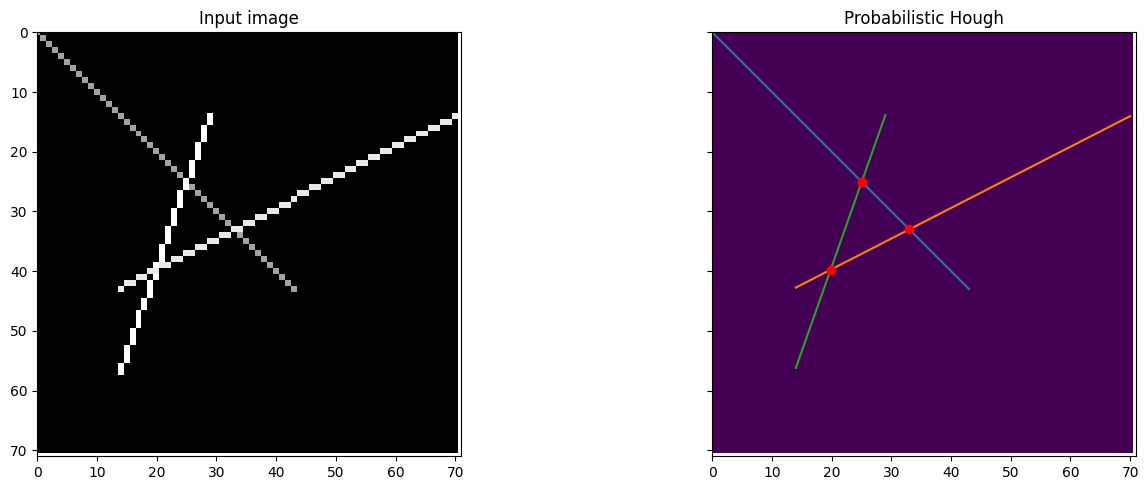

In [546]:

def calculate_slope_intercept(x1, y1, x2, y2):
    if x2 == x1:
        return None, None  # This indicates a vertical line
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    return slope, intercept

def find_intersection(slope1, intercept1, slope2, intercept2):
    if slope1 is None or slope2 is None:
        return None  # One or both lines are vertical
    if slope1 == slope2:
        return None  # Parallel lines
    x = (intercept2 - intercept1) / (slope1 - slope2)
    y = slope1 * x + intercept1
    return x, y

def all_intersections(lines):
    intersections = []
    print(f"Lines: {lines}")
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            line1 = lines[i]
            line2 = lines[j]

            slope1, intercept1 = calculate_slope_intercept(*line1[0], *line1[1])
            slope2, intercept2 = calculate_slope_intercept(*line2[0], *line2[1])

            if slope1 is not None and slope2 is not None:
                intersection = find_intersection(slope1, intercept1, slope2, intercept2)
                if intersection:
                    intersections.append(intersection)
            # Add handling for vertical lines if needed

    return intersections

# Find intersections
intersections = all_intersections(unioned_lines)
print(intersections)
print(f"Lines found: {len(unioned_lines)}")
print(f"INtersection points found: {len(intersections)}")

# Generating figure 2
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=cm.gray)
ax[0].set_title('Input image')

ax[1].imshow(edges * 0)
for line in unioned_lines:
    p0, p1 = line
    ax[1].plot((p0[0], p1[0]), (p0[1], p1[1]))
for point in intersections:
    ax[1].plot(point[0], point[1], 'ro')  # mark intersection
ax[1].set_xlim((0, image.shape[1]))
ax[1].set_ylim((image.shape[0], 0))
ax[1].set_title('Probabilistic Hough')

# for a in ax:
    # a.set_axis_off()

plt.tight_layout()
plt.show()


Lines found: 3
[(19.299684542586746, 41.160883280757105), (33.53488372093024, 33.534883720930225), (25.052631578947366, 25.05263157894737)]
Intersection points found: 3
Lines detected: [[[14, 44, 70, 14]], [[14, 56, 29, 14]], [[0, 0, 43, 43]]]
Ploting line: [14, 44, 70, 14]
Ploting line: [14, 56, 29, 14]
Ploting line: [0, 0, 43, 43]


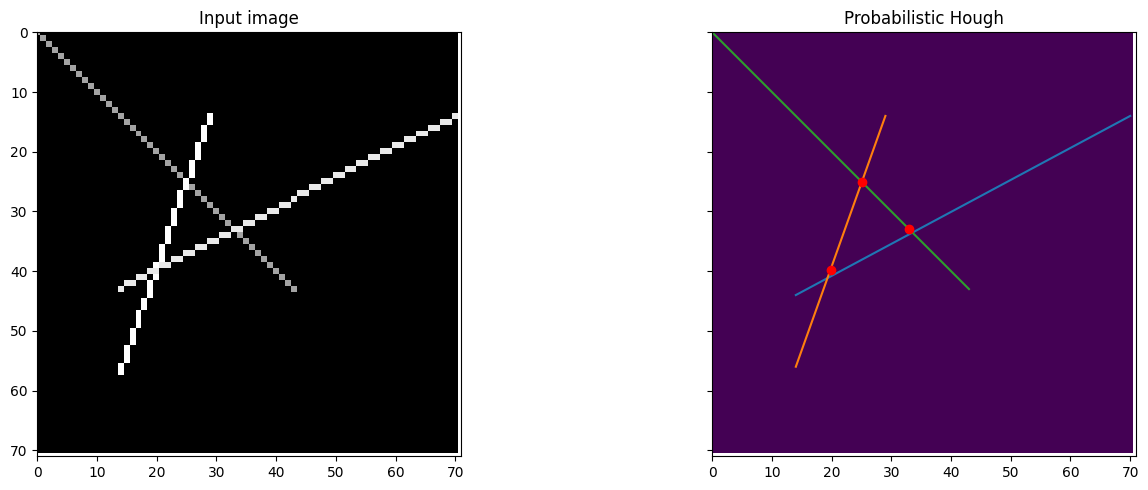

In [549]:
class LineDetector:

    def detect_lines(self, image):
        # Convert the image to grayscale if it's not already
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
        
        edges = canny(image, sigma=1.0, low_threshold=10, high_threshold=20)
        lines = probabilistic_hough_line(gray, threshold=10, line_length=2, line_gap=5)
        
        # Calculate angles for each line and store them
        angles = [self.calculate_angle(line) for line in lines]
        
        # Cluster lines by angle
        clusters = {}
        for idx, angle in enumerate(angles):
            found_cluster = False
            for cluster_angle in clusters.keys():
                if self.are_similar(angle, cluster_angle):
                    clusters[cluster_angle].append(lines[idx])
                    found_cluster = True
                    break
            if not found_cluster:
                clusters[angle] = [lines[idx]]
                
        # Assuming clusters is a dictionary with angles as keys and lists of lines as values
        unioned_lines = []

        for angle, lines_n in clusters.items():
            # Extract endpoints for all lines in the cluster
            x_coords = []
            y_coords = []
            for line in lines_n:
                p0, p1 = line
                x_coords.extend([p0[0], p1[0]])
                y_coords.extend([p0[1], p1[1]])
            
            # Perform linear regression on the endpoints
            A = np.vstack([x_coords, np.ones(len(x_coords))]).T
            m, c = np.linalg.lstsq(A, y_coords, rcond=None)[0]
            
            # Determine the new endpoints for the unioned line
            x_min, x_max = min(x_coords), max(x_coords)
            y_min, y_max = m*x_min + c, m*x_max + c
            
            # Add the new line to the list of unioned lines
            unioned_lines.append([[round(x_min), round(y_min), round(x_max), round(y_max)]])
        
        print(f"Lines found: {len(unioned_lines)}")
        intersections = self.all_intersections(unioned_lines)
        print(intersections)
        print(f"Intersection points found: {len(intersections)}")
        return unioned_lines
    
    def calculate_slope_intercept(self, x1, y1, x2, y2):
        if x2 == x1:
            return None, None  # This indicates a vertical line
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1
        return slope, intercept

    def find_intersection(self, slope1, intercept1, slope2, intercept2):
        if slope1 is None or slope2 is None:
            return None  # One or both lines are vertical
        if slope1 == slope2:
            return None  # Parallel lines
        x = (intercept2 - intercept1) / (slope1 - slope2)
        y = slope1 * x + intercept1
        return x, y
    
    def all_intersections(self, lines):
        intersections = []
        for i in range(len(lines)):
            for j in range(i + 1, len(lines)):
                line1 = lines[i][0]
                line2 = lines[j][0]

                slope1, intercept1 = calculate_slope_intercept(line1[0], line1[1], line1[2], line1[3])
                slope2, intercept2 = calculate_slope_intercept(line2[0], line2[1], line2[2], line2[3])

                if slope1 is not None and slope2 is not None:
                    intersection = self.find_intersection(slope1, intercept1, slope2, intercept2)
                    if intersection:
                        intersections.append(intersection)
                # Add handling for vertical lines if needed

        return intersections
    
    # A function to calculate the angle of a line
    def calculate_angle(self, line):
        p0, p1 = line
        return degrees(atan2(p1[1] - p0[1], p1[0] - p0[0]))

    # A function to check if two angles are similar
    def are_similar(self, angle1, angle2, threshold=5):
        return abs(angle1 - angle2) < threshold

    def merge_lines(self, lines_e):
        # Find the most extreme points in the grouped lines
        x_coords = [x for line in lines_e for x in (line[0][0], line[1][0])]
        y_coords = [y for line in lines_e for y in (line[0][1], line[1][1])]

        # Create a new line from the minimum and maximum points
        return (max(x_coords), max(y_coords)), (min(x_coords), min(y_coords))

        # Find the most extreme points in the grouped lines
        x_coords = [x for line in lines_e for x in (line[0][0], line[1][0])]
        y_coords = [y for line in lines_e for y in (line[0][1], line[1][1])]

        # Create a new line from the minimum and maximum points
        return (max(x_coords), max(y_coords)), (min(x_coords), min(y_coords))

# Generating figure 2
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
ax = axes.ravel()

image = cv2.imread("../../output/exported_img_comp.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
detector = LineDetector()
lines = detector.detect_lines(image)
print(f"Lines detected: {lines}")

ax[0].imshow(image, cmap=cm.gray)
ax[0].set_title('Input image')

ax[1].imshow(edges * 0)
for line in lines:
    line = line[0]
    print(f"Ploting line: {line}")
    ax[1].plot((line[0], line[2]), (line[1], line[3]))
for point in intersections:
    ax[1].plot(point[0], point[1], 'ro')  # mark intersection
ax[1].set_xlim((0, image.shape[1]))
ax[1].set_ylim((image.shape[0], 0))
ax[1].set_title('Probabilistic Hough')

# for a in ax:
    # a.set_axis_off()

plt.tight_layout()
plt.show()